"""
Focus:
- L2 Regularization
- Hyperparameter Tuning
- Coefficient Shrinkage
- Bias vs Variance Tradeoff
"""

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (train_test_split,cross_val_score,GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [2]:
# ============================================================
# STEP 1 : DATA UNDERSTANDING
# ============================================================

housing = fetch_california_housing()
df = pd.DataFrame(housing.data,columns=housing.feature_names)
df["Target"] = housing.target
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64
0


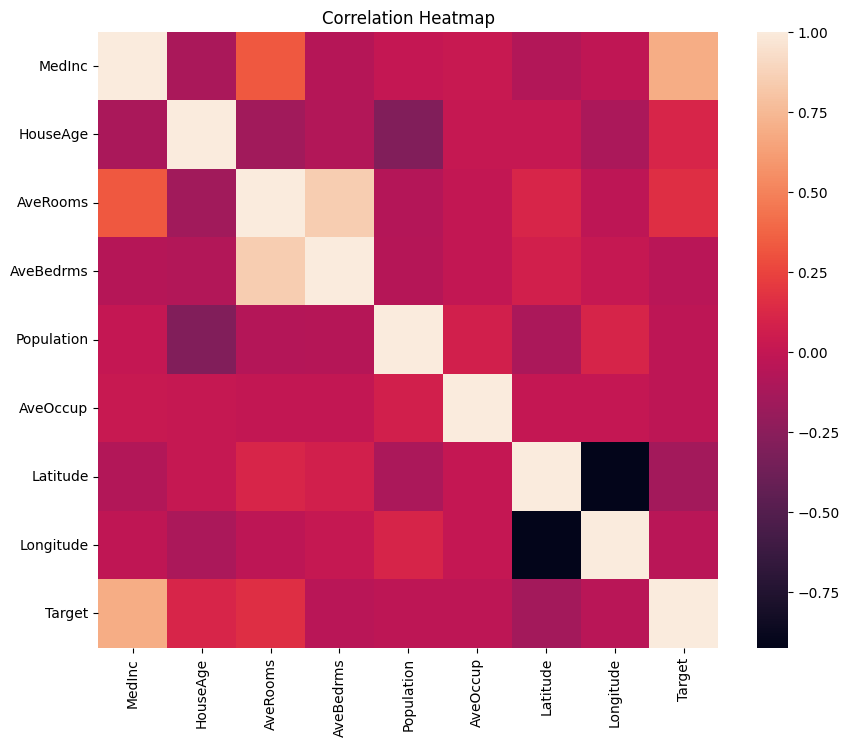

In [3]:
# ============================================================
# STEP 2 : EDA
# ============================================================

print(df.isnull().sum())
print(df.duplicated().sum())
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [4]:
# ============================================================
# STEP 3 : TRAIN / VALIDATION / TEST
# ============================================================

X = df.drop("Target", axis=1)
y = df["Target"]
X_temp, X_test, y_temp, y_test = train_test_split(X, y,test_size=0.15,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,test_size=0.1765,random_state=42)

In [5]:
# ============================================================
# STEP 4 : PREPROCESSING
# ============================================================

# Ridge is distance/coefficient based.
# Scaling is important.

pipe = Pipeline([("scaler", StandardScaler()),("model", Ridge(alpha=1.0,random_state=42))])

In [6]:
# ============================================================
# STEP 5 : BASELINE MODEL
# ============================================================

pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None


In [7]:
# ============================================================
# STEP 6 : VALIDATION check with base model
# ============================================================

y_pred = pipe.predict(X_val)
print("mae: ",mean_absolute_error(y_val,y_pred))
mse = mean_squared_error(y_val,y_pred)
print("mse: ",mse)
print("rmse: ",np.sqrt(mse))
r2 = r2_score(y_val,y_pred)
print("r2 score: ",r2)
n = len(y_val)
p = X_val.shape[1]
adj_r2 = 1 - (
    (1-r2)*(n-1)
)/(n-p-1)
print("adj_r2: ",adj_r2)

mae:  0.5307968125603743
mse:  0.515829830919178
rmse:  0.718212942600715
r2 score:  0.6144303688063957
adj_r2:  0.61343148375149


In [8]:
# ============================================================
# STEP 7 : CROSS VALIDATION
# ============================================================

cv_scores = cross_val_score(pipe,X_train,y_train,cv=5,scoring="r2",n_jobs=-1)
print("CV Mean:", cv_scores.mean())
print("CV Std :", cv_scores.std())

"""performed only on train data since If you use the test set during cross-validation, 
the model indirectly learns information about the test set, causing data leakage."""

CV Mean: 0.6025541044898439
CV Std : 0.0186905757504735


'performed only on train data since If you use the test set during cross-validation, \nthe model indirectly learns information about the test set, causing data leakage.'

In [11]:
# ============================================================
# STEP 8 : HYPERPARAMETER TUNING
# ============================================================

# Most important parameter:
# alpha increases
# -> More regularization

param_grid = {"model__alpha":[0.001,0.01,0.1,1,10,100]}
grid = GridSearchCV(pipe,param_grid,cv=5,scoring="r2",n_jobs=-1)
grid.fit(X_train, y_train)
print("best alpha is:",grid.best_params_)
print("best score is: ",grid.best_score_)
best_model = grid.best_estimator_
print(best_model)

best alpha is: {'model__alpha': 10}
best score is:  0.6025788758217152
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', Ridge(alpha=10, random_state=42))])


In [12]:
# ============================================================
# STEP 9 : VALIDATION check with best model
# ============================================================

y_best = best_model.predict(X_val)
val_r2 = r2_score(y_val, y_best)

In [13]:
# ============================================================
# STEP 10 : TRAIN vs VALIDATION prediction check
# ============================================================

y_train_best = best_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_best)

print("Train R2:", train_r2)
print("Val R2  :", val_r2)

Train R2: 0.6075796069447633
Val R2  : 0.6143860915978772


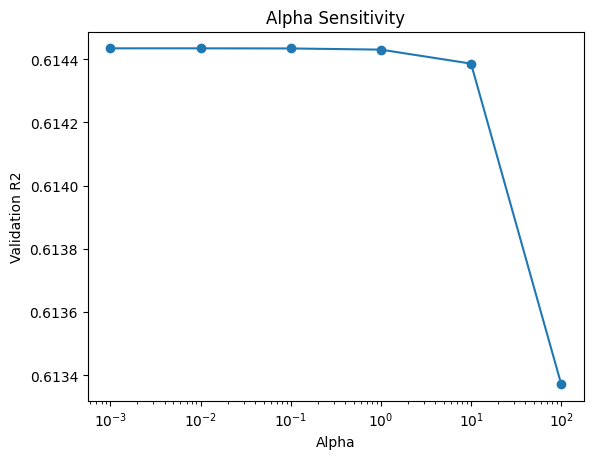

In [14]:
# ============================================================
# STEP 11 : RIDGE SPECIFIC ANALYSIS
# ============================================================

# Compare coefficient shrinkage

linear_pipe = Pipeline([("scaler", StandardScaler()),("model", LinearRegression())])
linear_pipe.fit(X_train, y_train)
linear_coef = linear_pipe.named_steps["model"].coef_
ridge_coef = best_model.named_steps["model"].coef_
coef_df = pd.DataFrame({"Feature": X.columns,"Linear": linear_coef,"Ridge": ridge_coef})

# Ridge shrinks coefficients toward zero
# but not exactly zero.

# Alpha sensitivity

alphas = [0.001,0.01,0.1,1,10,100]
scores = []

for alpha in alphas:
    temp_pipe = Pipeline([("scaler", StandardScaler()),("model", Ridge(alpha=alpha,random_state=42))])

    temp_pipe.fit(X_train, y_train)
    pred = temp_pipe.predict(X_val)
    scores.append(r2_score(y_val, pred))

plt.plot(alphas, scores, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Validation R2")
plt.title("Alpha Sensitivity")
plt.show()

In [15]:
# ============================================================
# STEP 12 : FINAL MODEL FREEZE
# ============================================================
final_model = best_model

In [16]:
# ============================================================
# STEP 13 : TEST EVALUATION
# ============================================================

test_pred = final_model.predict(X_test)
test_mae = mean_absolute_error(y_test,test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test,test_pred))
test_r2 = r2_score(y_test,test_pred)

print("TEST MAE :", test_mae)
print("TEST RMSE:", test_rmse)
print("TEST R2  :", test_r2)

TEST MAE : 0.5353683924459651
TEST RMSE: 0.7328566339557117
TEST R2  : 0.5901750169438327


In [ ]:
# ============================================================
# STEP 14 : INTERPRETATION
# ============================================================

ridge_model = final_model.named_steps["model"]
coef_df = pd.DataFrame({"Feature": X.columns,"Coefficient": ridge_model.coef_}).sort_values(by="Coefficient",ascending=False)
ridge_model.intercept_

In [17]:
# ============================================================
# STEP 15 : DEPLOYMENT READINESS
# ============================================================

print("CV Mean:", cv_scores.mean())
print("Validation R2:", val_r2)
print("Test R2:", test_r2)

CV Mean: 0.6025541044898439
Validation R2: 0.6143860915978772
Test R2: 0.5901750169438327


# ============================================================
# INTERVIEW QUESTIONS
# ============================================================

"""
1. Why was Ridge Regression introduced?
2. What is L2 Regularization?
3. Ridge cost function?
4. What does alpha control?
5. What happens when alpha=0?
6. What happens when alpha is very large?
7. Can Ridge perform feature selection?
   No. Coefficients shrink but rarely become zero.
8. Difference between Linear Regression and Ridge?
9. Difference between Ridge and Lasso?
10. Why scaling is important for Ridge?
11. What is coefficient shrinkage?
12. How does Ridge help multicollinearity?
13. What is bias-variance tradeoff?
14. Why GridSearchCV?
15. Why tune alpha using validation/CV instead of test set?
"""